# Partition

In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.helpers.predicates import above_35, below_35
from programming_first_principles.helpers.cost import Cost

import random
import inspect
import copy
from collections import namedtuple
from pprint import pprint

In [ ]:
#| hide
prepare_notebook()

In [ ]:
#| hide
#| default_exp algorithms.partition

In [ ]:
scores = [random.randint(1, 100) for _ in range(100)]
random.shuffle(scores)
pprint(scores,compact=True, width=80)

[12, 23, 8, 43, 30, 6, 25, 12, 95, 29, 80, 70, 44, 19, 15, 20, 34, 31, 60, 73,
 77, 91, 91, 45, 2, 24, 73, 92, 76, 99, 67, 10, 98, 56, 40, 43, 60, 36, 90, 48,
 48, 98, 79, 29, 17, 20, 7, 100, 15, 33, 28, 53, 72, 76, 45, 63, 74, 98, 63, 45,
 19, 99, 44, 9, 19, 74, 69, 64, 8, 92, 27, 33, 58, 19, 14, 27, 18, 87, 10, 47,
 15, 56, 73, 21, 40, 5, 91, 13, 50, 12, 29, 48, 64, 16, 4, 79, 78, 73, 88, 51]


In [ ]:
print(inspect.getsource(above_35))

def above_35(score):
    """Return whether score is 35 or higher."""
    return score >= 35



#### Single Pass
* Lomuto

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap
def partition_single_pass(a, pred):
    n = 0
    for i in range(len(a)):
        if pred(a[i]):
            if n != i:
                swap(a, n, i)
            n += 1
    return n

In [ ]:
scores_sp = [5, 40, 3, 10, 20, 60,75,80]
partition_point= partition_single_pass(scores_sp, above_35)
f'Good: {scores_sp[:partition_point] = }'
f'Bad: {scores_sp[partition_point:] = }'

'Good: scores_sp[:partition_point] = [40, 60, 75, 80]'

'Bad: scores_sp[partition_point:] = [20, 5, 3, 10]'

In [ ]:
scores_b = copy.copy(scores)
partition_point= partition_single_pass(scores_b, above_35)
f'{partition_point = }'
f'Good: {scores_b[:partition_point] = }'
f'Bad: {scores_b[partition_point:] = }'

'partition_point = 58'

'Good: scores_b[:partition_point] = [43, 95, 80, 70, 44, 60, 73, 77, 91, 91, 45, 73, 92, 76, 99, 67, 98, 56, 40, 43, 60, 36, 90, 48, 48, 98, 79, 100, 53, 72, 76, 45, 63, 74, 98, 63, 45, 99, 44, 74, 69, 64, 92, 58, 87, 47, 56, 73, 40, 91, 50, 48, 64, 79, 78, 73, 88, 51]'

'Bad: scores_b[partition_point:] = [25, 12, 19, 23, 29, 9, 19, 8, 2, 24, 8, 12, 27, 33, 29, 19, 14, 27, 18, 17, 10, 20, 15, 7, 30, 21, 15, 5, 33, 13, 28, 12, 29, 19, 15, 16, 4, 20, 10, 34, 31, 6]'

In [ ]:
scores_sp_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_single_pass, scores_sp_cost, lambda x: x < 35, operations=('predicates','ms'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,,8,None,8,None,0.0038


In [ ]:
pred = lambda data: (lambda x: x < 5_000,)
single_pass = Cost(repeats=5, seed=0)
_ = single_pass.scale([partition_single_pass], args=pred, operations=('predicates','swaps','ms'))

single_pass.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,random,500,None,500,258,0.0458
1,partition_single_pass,sorted,500,None,500,0,0.0244
2,partition_single_pass,reversed,500,None,500,258,0.0602
3,partition_single_pass,random,1000,None,1000,501,0.1128
4,partition_single_pass,sorted,1000,None,1000,0,0.0750
5,partition_single_pass,reversed,1000,None,1000,501,0.0905
6,partition_single_pass,random,2000,None,2000,988,0.1836
7,partition_single_pass,sorted,2000,None,2000,0,0.1239
8,partition_single_pass,reversed,2000,None,2000,991,0.2358


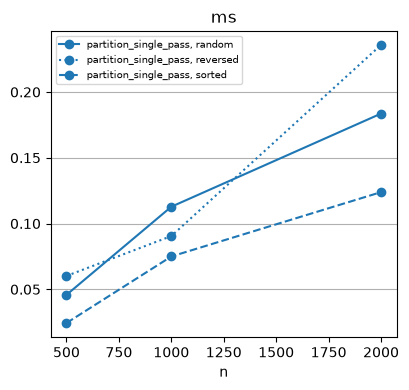

In [ ]:
single_pass.plot('ms')

In [ ]:
from programming_first_principles.algorithms.rearrange import swap
def v_partition_single_pass(b, pred):
    n = 0
    a = list(b)
    for i in range(len(a)):
        val  = a[i]
        predicate = pred(val)
        if predicate:
            if n != i:
                swap(a, n, i)
            n += 1
        array_state = a[:]
    return n, a

In [ ]:
scores_vsp = [5, 40, 3, 10, 20, 60,75,80]
# LiveEdit.inspect_run(v_partition_single_pass, scores_vsp, above_35)

#### Two Pointer
* Hoare

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap
def partition_two_pointer(a, pred):
    lo, hi = 0, len(a) - 1
    while lo <= hi:
        if pred(a[lo]):
            lo += 1
        else:
            if not pred(a[hi]):
                hi -= 1
            else:
                swap(a, lo, hi)
                lo += 1
                hi -= 1
    return lo

In [ ]:
scores_2p = [5, 40, 3, 10, 20, 60,75,80]
partition_point1 = partition_two_pointer(scores_2p, above_35)
f'{partition_point1 = }'
f'Passed: {scores_2p[:partition_point1] = }'
f'Failed: {scores_2p[partition_point1:] = }'

'partition_point1 = 4'

'Passed: scores_2p[:partition_point1] = [80, 40, 75, 60]'

'Failed: scores_2p[partition_point1:] = [20, 10, 3, 5]'

In [ ]:
scores_d = copy.copy(scores)
n1 = partition_two_pointer(scores_d, above_35)
f'{n1 = }'
f'Passed: {scores_d[:n1] = }'
f'Failed: {scores_d[n1:] = }'

'n1 = 58'

'Passed: scores_d[:n1] = [51, 88, 73, 43, 78, 79, 64, 48, 95, 50, 80, 70, 44, 91, 40, 73, 56, 47, 60, 73, 77, 91, 91, 45, 87, 58, 73, 92, 76, 99, 67, 92, 98, 56, 40, 43, 60, 36, 90, 48, 48, 98, 79, 64, 69, 74, 44, 100, 99, 45, 63, 53, 72, 76, 45, 63, 74, 98]'

'Failed: scores_d[n1:] = [28, 33, 19, 15, 7, 9, 19, 20, 17, 29, 8, 10, 27, 33, 24, 19, 14, 27, 18, 2, 10, 31, 15, 34, 20, 21, 15, 5, 19, 13, 29, 12, 29, 12, 25, 16, 4, 6, 30, 8, 23, 12]'

In [ ]:
scores_2p_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_two_pointer, scores_2p_cost, lambda x: x < 35, operations=('predicates','ms'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,,8,None,11,None,0.0035


In [ ]:
two_pointer = Cost(repeats=1, seed=0)
_ = two_pointer.scale([partition_two_pointer], 
                        args=pred,
                        operations=('predicates','swaps','ms'))
two_pointer.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,random,500,None,614,128,0.0605
1,partition_two_pointer,sorted,500,None,742,0,0.0417
2,partition_two_pointer,reversed,500,None,500,242,0.0465
3,partition_two_pointer,random,1000,None,1257,242,0.1075
4,partition_two_pointer,sorted,1000,None,1499,0,0.0760
5,partition_two_pointer,reversed,1000,None,1000,499,0.0852
6,partition_two_pointer,random,2000,None,2496,513,0.3140
7,partition_two_pointer,sorted,2000,None,3009,0,0.1574
8,partition_two_pointer,reversed,2000,None,2018,991,0.1697


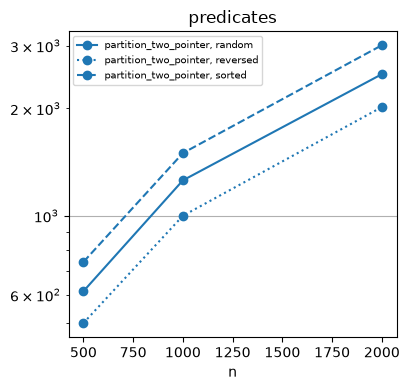

In [ ]:
two_pointer.plot('predicates')

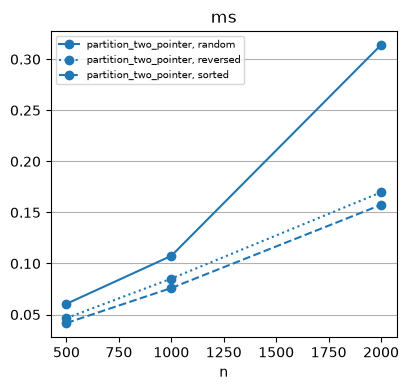

In [ ]:
two_pointer.plot('ms')

#### Custom Data Type

In [ ]:
Student = namedtuple("Student", ["name", "score"])

def student_above_35(s):
    return above_35(s.score)

students = [
    Student("Ana", 22),
    Student("Ben", 41),
    Student("Cai", 35),
    Student("Diya", 90),
    Student("Eli", 18),
    Student("Far", 67),
]

n = partition_two_pointer(students, student_above_35)

f'Passed: {students[:n]}'

"Passed: [Student(name='Far', score=67), Student(name='Ben', score=41), Student(name='Cai', score=35), Student(name='Diya', score=90)]"

#### Is Partitioned

In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if, find_if_not

def is_partitioned(a, first, last, pred):
    i = find_if_not(a, first, last, pred)
    j = find_if(a, i, last, pred )
    return j == last

In [ ]:
scores_isp = [5, 40, 3, 10, 20, 60,75,80]

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'
partition_point1 = partition_single_pass(scores_isp, above_35)
f'{scores_isp = }'

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = False'

'scores_isp = [40, 60, 75, 80, 20, 5, 3, 10]'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = True'

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

isp = Cost(repeats=1)
_ = isp.run(is_partitioned, good, 0, len(good), above_35,
            shape='partitioned', operations=('predicates', 'ms'))
_ = isp.run(is_partitioned, raw, 0, len(raw), above_35,
            shape='broken', operations=('predicates', 'ms'))
isp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,is_partitioned,partitioned,8,None,9,None,0.0028
1,is_partitioned,broken,8,None,3,None,0.0016


#### Partition Point

In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if_not
def partition_point_linear(a, first, last, pred):
    return find_if_not(a, first, last, pred)

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

f'{partition_point_linear(good, 0, len(good), above_35) = }'
f'{partition_point_linear(raw, 0, len(raw), above_35) = }'

'partition_point_linear(good, 0, len(good), above_35) = 4'

'partition_point_linear(raw, 0, len(raw), above_35) = 0'

In [ ]:
front = [5, 3, 10, 20, 8, 1, 2, 4]
mid = [40, 60, 75, 80, 20, 5, 3, 10]
end = [40, 60, 75, 80, 90, 41, 35, 50]

ppl = Cost(repeats=1)
_ = ppl.run(partition_point_linear, front, 0, len(front), above_35,
           shape='point 0', operations=('predicates', 'ms'))
_ = ppl.run(partition_point_linear, mid, 0, len(mid), above_35,
           shape='point 4', operations=('predicates', 'ms'))
_ = ppl.run(partition_point_linear, end, 0, len(end), above_35,
           shape='point 8', operations=('predicates', 'ms'))
ppl.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_point_linear,point 0,8,None,1,None,0.0019
1,partition_point_linear,point 4,8,None,5,None,0.0018
2,partition_point_linear,point 8,8,None,8,None,0.0015


In [ ]:
#| exports  
def partition_point(a, first, last, pred):
    """
    Precondition: is_partitioned(a, first, last, pred).
    Returns the partition point of [first, last).
    """
    while first != last:
        middle = first + (last - first) // 2
        if pred(a[middle]):
            first = middle + 1
        else:
            last = middle
    return first

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]
f'{is_partitioned(good, 0, len(good), above_35) = }'
f'{partition_point(good, 0, len(good), above_35) = }'

f'{is_partitioned(raw, 0, len(raw), above_35) = }'
f'{partition_point(raw, 0, len(raw), above_35) = }'

'is_partitioned(good, 0, len(good), above_35) = True'

'partition_point(good, 0, len(good), above_35) = 4'

'is_partitioned(raw, 0, len(raw), above_35) = False'

'partition_point(raw, 0, len(raw), above_35) = 2'

In [ ]:
front = [5, 3, 10, 20, 8, 1, 2, 4]
mid = [40, 60, 75, 80, 20, 5, 3, 10]
end = [40, 60, 75, 80, 90, 41, 35, 50]

pp = Cost(repeats=1)
_ = pp.run(partition_point, front, 0, len(front), above_35,
           shape='point 0', operations=('predicates', 'ms'))
_ = pp.run(partition_point, mid, 0, len(mid), above_35,
           shape='point 4', operations=('predicates', 'ms'))
_ = pp.run(partition_point, end, 0, len(end), above_35,
           shape='point 8', operations=('predicates', 'ms'))
pp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_point,point 0,8,None,4,None,0.0024
1,partition_point,point 4,8,None,3,None,0.0021
2,partition_point,point 8,8,None,3,None,0.0028


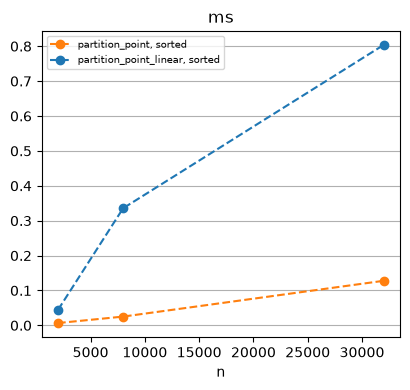

In [ ]:
point = Cost(repeats=5, seed=0, sizes=(2_000, 8_000, 32_000))
_ = point.scale(
    [partition_point_linear, partition_point],
    args=lambda data: (0, len(data), lambda x: x < 5_000),
    operations=('ms',),
)
point.plot('ms', frame=point.frame[point.frame['shape'] == 'sorted'])